In [10]:
from google.colab import files
import pydicom
import numpy as np
from pydicom.uid import ImplicitVRLittleEndian
from PIL import Image

def convert_dicom_to_png(dicom_file):

    # Force read
    ds = pydicom.dcmread(dicom_file, force=True)

    # If TransferSyntaxUID is missing → set default
    if not hasattr(ds.file_meta, "TransferSyntaxUID"):
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian

    # Now safely decode pixel data
    try:
        pixel_array = ds.pixel_array.astype(float)
    except Exception as e:
        raise RuntimeError(f"Unable to decode pixel data: {e}")

    # Normalize 0–255
    pixel_array = (pixel_array - pixel_array.min()) / (pixel_array.max() - pixel_array.min())
    pixel_array = (pixel_array * 255).astype(np.uint8)

    img = Image.fromarray(pixel_array)

    output_name = dicom_file.replace(".dcm", ".png")
    img.save(output_name)

    print("Conversion successful! Downloading PNG...")
    files.download(output_name)



print("Upload a DICOM (.dcm) file:")
uploaded = files.upload()

for fname in uploaded.keys():
    convert_dicom_to_png(fname)


Upload a DICOM (.dcm) file:


KeyboardInterrupt: 

Upload your PNG file:


Saving 00001075_000.png to 00001075_000 (2).png
Processed image generated. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

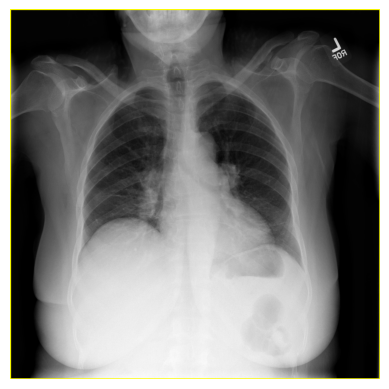

In [9]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def process_image_full_bbox(image_path, output_name="processed.png"):
    # Load image
    img = Image.open(image_path).convert("RGB")
    width, height = img.size

    # FULL bounding box covering entire image
    x1, y1 = 0, 0
    x2, y2 = width - 1, height - 1

    # Draw bounding box
    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], outline="yellow", width=3)

    # Crop to bounding box (removes extra borders / padding)
    cropped = img.crop((x1, y1, x2, y2))

    # Save and return
    cropped.save(output_name)
    print("Processed image generated. Downloading...")
    files.download(output_name)

    # Display
    plt.imshow(cropped)
    plt.axis("off")
    plt.show()

print("Upload your PNG file:")
uploaded = files.upload()

filename = next(iter(uploaded))
process_image_full_bbox(filename)
